In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('thyroid_dataset.csv')

In [3]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [4]:
X = df.drop('Outlier_label', axis = 1)
Y = df['Outlier_label']

In [5]:
X.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,61.0,6.0,23.0,87.0,26.0
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,29.0,15.0,61.0,96.0,64.0
2,0.16,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,29.0,19.0,58.0,103.0,56.0
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,114.0,3.0,24.0,61.0,39.0
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,49.0,3.0,5.0,116.0,4.0


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(n_estimators = 200, contamination = 'auto', random_state = 42)

In [8]:
labels = clf.fit_predict(X_scaled)

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

Text(0, 0.5, 'pC2')

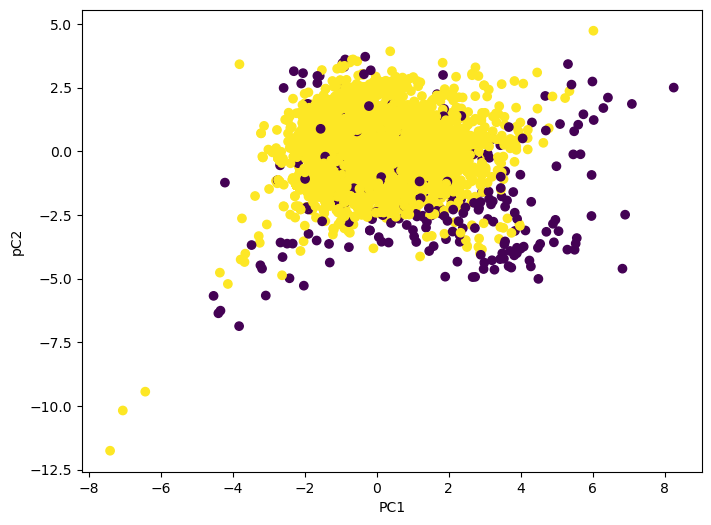

In [10]:
plt.figure(figsize = (8,6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c = labels)
plt.xlabel('PC1')
plt.ylabel('pC2')

In [11]:
import numpy as np

n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print('Outlier = ', n_outliers)
print('Normal = ', n_normal)

Outlier =  270
Normal =  6646


In [12]:
from sklearn.neighbors import LocalOutlierFactor

In [13]:
neighbs = LocalOutlierFactor()

labels = neighbs.fit_predict(X_scaled)

Text(0, 0.5, 'pC2')

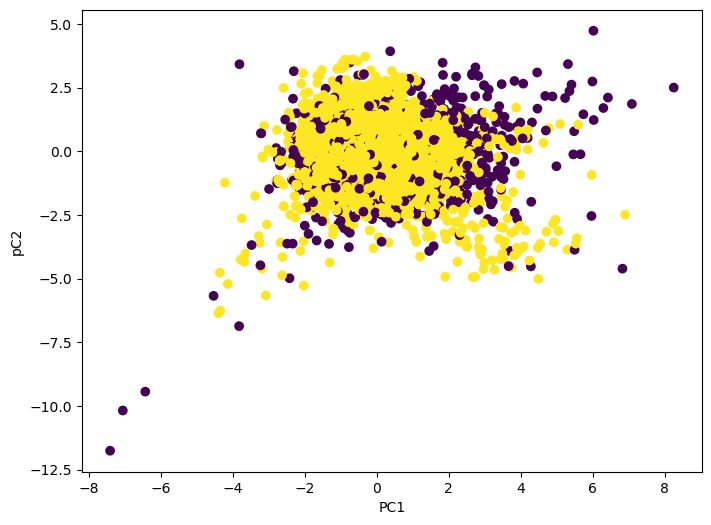

In [14]:
plt.figure(figsize = (8,6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c = labels)
plt.xlabel('PC1')
plt.ylabel('pC2')

In [15]:
n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print('Outlier = ', n_outliers)
print('Normal = ', n_normal)

Outlier =  883
Normal =  6033
